
# Abbiategrasso: finanza comunale minimale

Terzo filone locale della repo.

Obiettivo:
- leggere la composizione minima delle entrate correnti di Abbiategrasso
- confrontare Abbiategrasso con gli stessi 6 comuni gia' usati nel benchmark locale
- capire se il comune si regge soprattutto su entrate proprie, trasferimenti o altre componenti


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

project_root = Path.cwd().resolve().parent
data_path = project_root / 'data' / 'abbiategrasso_finanza_minimale_2021_2025.csv'
figures_path = project_root / 'figures'
figures_path.mkdir(exist_ok=True)
assert data_path.exists(), data_path

df = pd.read_csv(data_path)
df.head()


,anno,comune,codice_ente,macro_categoria_v2,importo_eur,totale_entrate_correnti_eur,quota_pct
0,2021,ABBIATEGRASSO,270622,Altro,"5,928,576.81","26,233,770.16",22.60
1,2021,ABBIATEGRASSO,270622,Contributi agli investimenti,"999,996.26","26,233,770.16",3.81
2,2021,ABBIATEGRASSO,270622,Fondi perequativi,"3,354,957.82","26,233,770.16",12.79
3,2021,ABBIATEGRASSO,270622,Imposte proprie,"11,378,057.44","26,233,770.16",43.37
4,2021,ABBIATEGRASSO,270622,Trasferimenti correnti,"4,572,181.83","26,233,770.16",17.43


## 1. Abbiategrasso tra 2021 e 2025

In [2]:

abb = df[df['comune'] == 'ABBIATEGRASSO'].copy()
abb_pivot = abb.pivot(index='macro_categoria_v2', columns='anno', values='quota_pct').reset_index()
abb_pivot['delta_pp'] = abb_pivot[2025] - abb_pivot[2021]
abb_pivot.sort_values('quota_pct' if 'quota_pct' in abb_pivot.columns else 2025, ascending=False)


anno,macro_categoria_v2,2021,2025,delta_pp
3,Imposte proprie,43.37,39.70,-3.67
0,Altro,22.60,28.05,5.45
4,Trasferimenti correnti,17.43,14.02,-3.41
2,Fondi perequativi,12.79,10.14,-2.65
1,Contributi agli investimenti,3.81,8.09,4.28


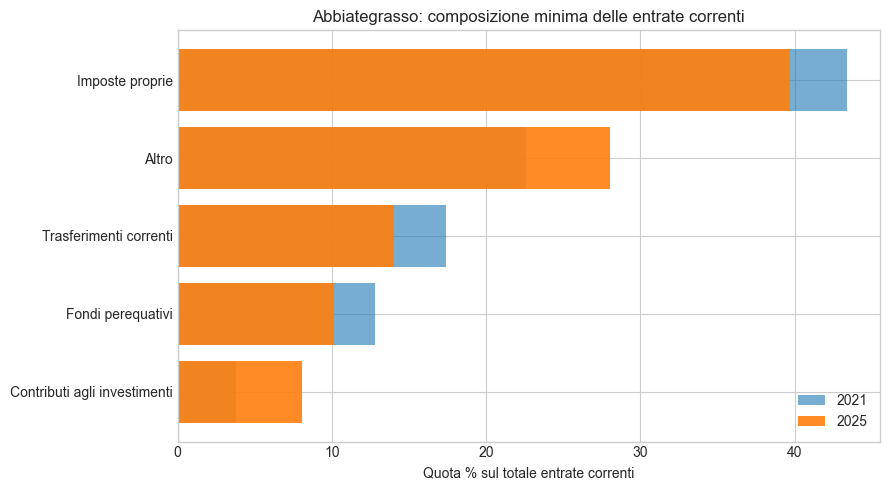

In [3]:
plot_df = abb_pivot.sort_values(2025, ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df['macro_categoria_v2'], plot_df[2021], label='2021', alpha=0.6)
ax.barh(plot_df['macro_categoria_v2'], plot_df[2025], label='2025', alpha=0.9)
ax.set_title('Abbiategrasso: composizione minima delle entrate correnti')
ax.set_xlabel('Quota % sul totale entrate correnti')
ax.legend()
plt.tight_layout()
fig.savefig(figures_path / 'abbiategrasso_finanza_composizione_2021_2025.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Benchmark 2025 sui 6 comuni

In [4]:

benchmark_2025 = df[df['anno'] == 2025].copy()
focus = benchmark_2025[benchmark_2025['macro_categoria_v2'].isin(['Imposte proprie', 'Fondi perequativi', 'Trasferimenti correnti'])]
bench_pivot = focus.pivot(index='comune', columns='macro_categoria_v2', values='quota_pct').reset_index()
bench_pivot.sort_values('Imposte proprie', ascending=False)


macro_categoria_v2,comune,Fondi perequativi,Imposte proprie,Trasferimenti correnti
5,VIGEVANO,11.12,44.49,14.94
4,ROZZANO,13.59,43.57,17.58
3,MAGENTA,5.39,43.05,20.02
2,CORSICO,19.24,42.92,8.76
0,ABBIATEGRASSO,10.14,39.70,14.02
1,BUCCINASCO,10.45,38.24,10.23


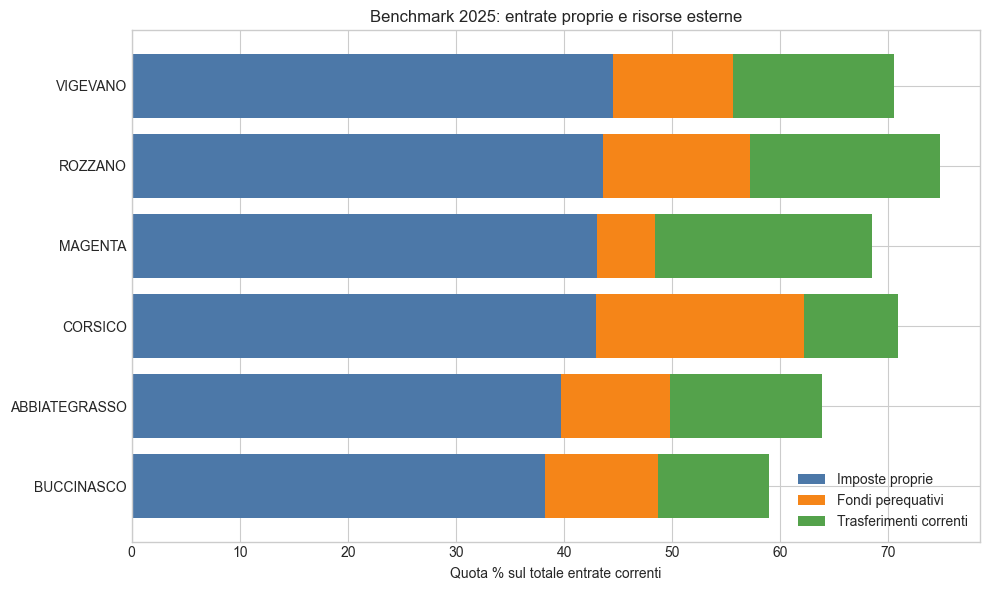

In [5]:
plot_df = bench_pivot.sort_values('Imposte proprie', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['comune'], plot_df['Imposte proprie'], label='Imposte proprie', color='#4c78a8')
ax.barh(plot_df['comune'], plot_df['Fondi perequativi'], left=plot_df['Imposte proprie'], label='Fondi perequativi', color='#f58518')
left = plot_df['Imposte proprie'] + plot_df['Fondi perequativi']
ax.barh(plot_df['comune'], plot_df['Trasferimenti correnti'], left=left, label='Trasferimenti correnti', color='#54a24b')
ax.set_title('Benchmark 2025: entrate proprie e risorse esterne')
ax.set_xlabel('Quota % sul totale entrate correnti')
ax.legend(loc='lower right')
plt.tight_layout()
fig.savefig(figures_path / 'abbiategrasso_finanza_benchmark_2025.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Sintesi minima

In [6]:
summary = bench_pivot.sort_values('Imposte proprie', ascending=False).copy()
summary['risorse_esterne'] = summary['Fondi perequativi'] + summary['Trasferimenti correnti']
summary


macro_categoria_v2,comune,Fondi perequativi,Imposte proprie,Trasferimenti correnti,risorse_esterne
5,VIGEVANO,11.12,44.49,14.94,26.06
4,ROZZANO,13.59,43.57,17.58,31.17
3,MAGENTA,5.39,43.05,20.02,25.41
2,CORSICO,19.24,42.92,8.76,28.00
0,ABBIATEGRASSO,10.14,39.70,14.02,24.16
1,BUCCINASCO,10.45,38.24,10.23,20.68



### Lettura iniziale

- ad Abbiategrasso le **imposte proprie** restano la componente principale e crescono leggermente tra `2021` e `2025`
- **fondi perequativi** e **trasferimenti correnti** pesano meno delle entrate proprie, ma insieme restano una parte non marginale del profilo finanziario
- nel benchmark `2025`, Abbiategrasso non e' tra i comuni piu' dipendenti da risorse esterne, ma neppure tra quelli piu' sbilanciati sulle entrate proprie
- il blocco `Altro` resta ampio: per una lettura piu' forte servirebbe un secondo passaggio su alcune voci puntuali del mart SIOPE
